# 02 - Entraînement des modèles (OLS, Random Forest, XGBoost)


In [ ]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import joblib
import os

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from src.config import MODELS_DIR, RANDOM_STATE


In [18]:
# Création du dossier models
os.makedirs(MODELS_DIR, exist_ok=True)


# =========================
# 1. Chargement des données
# =========================

In [ ]:
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")

y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

print(f"Train : {X_train.shape}, Test : {X_test.shape}")


Train : (16512, 11), Test : (4128, 11)


# =========================
# 2. Preprocessing 
# =========================

In [ ]:


#  Encoding (categorical → numeric)
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

#  Align columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

#  Fill NaN (important)
X_train = X_train.fillna(X_train.median())
X_test = X_test.fillna(X_train.median())

#  Convert to numeric (sécurité)
X_train = X_train.apply(pd.to_numeric, errors='coerce')
X_test = X_test.apply(pd.to_numeric, errors='coerce')

#  Final clean
X_train = X_train.fillna(0)
X_test = X_test.fillna(0)

#  Force float
X_train = X_train.astype(float)
X_test = X_test.astype(float)

#  Vérification
print("\nTypes après preprocessing:")
print(X_train.dtypes.value_counts())

print("\nShapes finaux:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)



Types après preprocessing:
float64    11
Name: count, dtype: int64

Shapes finaux:
X_train: (16512, 11)
X_test : (4128, 11)


# =========================
# 3. Modèle OLS
# =========================

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("\n=== Régression Linéaire OLS ===")
print(f"RMSE : {rmse_lr:.4f}")
print(f"MAE  : {mae_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")


=== Régression Linéaire OLS ===
RMSE : 67664.8787
MAE  : 48626.9773
R²   : 0.6506



# =========================
# 4. Random Forest
# =========================

In [ ]:
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("\n=== Random Forest ===")
print(f"RMSE : {rmse_rf:.4f}")
print(f"MAE  : {mae_rf:.4f}")
print(f"R²   : {r2_rf:.4f}")



=== Random Forest ===
RMSE : 53145.2836
MAE  : 35268.5399
R²   : 0.7845


# =========================
# 5. XGBoost
# =========================

In [ ]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("\n=== XGBoost ===")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"MAE  : {mae_xgb:.4f}")
print(f"R²   : {r2_xgb:.4f}")


=== XGBoost ===
RMSE : 47085.4820
MAE  : 30845.8178
R²   : 0.8308


# =========================
# 6. Sauvegarde des modèles
# =========================

In [ ]:
joblib.dump(lr, os.path.join(MODELS_DIR, "linear_regression.pkl"))
joblib.dump(rf, os.path.join(MODELS_DIR, "random_forest.pkl"))
joblib.dump(xgb_model, os.path.join(MODELS_DIR, "xgboost.pkl"))

print("\n✅ Modèles sauvegardés dans :", MODELS_DIR)


✅ Modèles sauvegardés dans : c:\Users\hp\Downloads\pfe_comparaison_modeles3\models


# =========================================================
# Distribution des erreurs absolues par modèles
# =========================================================

C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\hp\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN bef

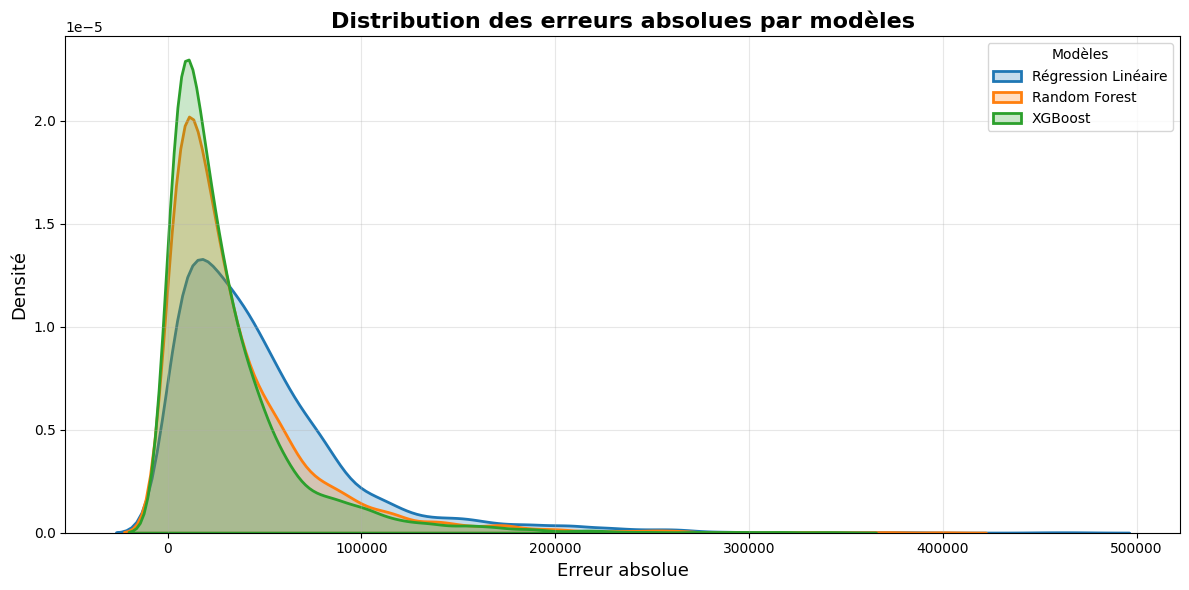

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------------------------------------
# Calcul des erreurs absolues
# ---------------------------------------------------------

# Exemple :
# y_test = vraies valeurs
# y_pred_lr = prédictions Linear Regression
# y_pred_rf = prédictions Random Forest
# y_pred_xgb = prédictions XGBoost

erreurs = pd.DataFrame({
    "Régression Linéaire": np.abs(y_test - y_pred_lr),
    "Random Forest": np.abs(y_test - y_pred_rf),
    "XGBoost": np.abs(y_test - y_pred_xgb)
})

# ---------------------------------------------------------
# Figure
# ---------------------------------------------------------

plt.figure(figsize=(12,6))

for colonne in erreurs.columns:
    sns.kdeplot(
        erreurs[colonne],
        fill=True,
        linewidth=2,
        label=colonne
    )

plt.title("Distribution des erreurs absolues par modèles",
          fontsize=16,
          fontweight='bold')

plt.xlabel("Erreur absolue", fontsize=13)
plt.ylabel("Densité", fontsize=13)

plt.legend(title="Modèles")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/Distribution_des_erreurs_absolues_par_modèles.png", dpi=150)
plt.show()

#  Explications – Entraînement des modèles

---

## 1. Régression linéaire (Ordinary Least Squares)

On suppose une relation linéaire entre les prédicteurs \(X\) et la cible \(y\) :

$$
y = X\beta + \varepsilon
$$

L’estimateur OLS minimise la somme des carrés des résidus :

$$
\hat{\beta} = \arg\min_{\beta} \|y - X\beta\|_2^2
$$

Lorsque \(X^T X\) est inversible, la solution explicite est :

$$
\hat{\beta} = (X^T X)^{-1} X^T y
$$

---

## 2. Random Forest

Forêt aléatoire : ensemble d’arbres de décision. Chaque arbre \(T_b\) est construit sur un échantillon bootstrap et sur un sous‑ensemble aléatoire de variables.

La prédiction finale est la moyenne des prédictions individuelles :

$$
\hat{y} = \frac{1}{B} \sum_{b=1}^{B} T_b(x)
$$

où \(B\) est le nombre d’arbres.

---

## 3. XGBoost (Extreme Gradient Boosting)

Méthode de boosting itérative. À chaque étape \(t\), un nouvel arbre \(f_t\) est ajouté pour corriger les résidus du modèle précédent :

$$
\hat{y}^{(t)} = \hat{y}^{(t-1)} + \eta \cdot f_t(x)
$$

\(\eta\) est le taux d’apprentissage (`learning_rate`).

La fonction objectif à minimiser inclut une régularisation :

$$
\mathcal{L}^{(t)} = \sum_{i=1}^{n} \ell\big(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)\big) + \Omega(f_t)
$$

avec \(\ell\) la fonction de perte (erreur quadratique) et \(\Omega(f_t)\) une pénalité sur la complexité de l’arbre.

---

## 4. Métriques d’évaluation

**RMSE (Root Mean Squared Error)** :

$$
\text{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

**MAE (Mean Absolute Error)** :

$$
\text{MAE} = \frac{1}{n}\sum_{i=1}^{n} |y_i - \hat{y}_i|
$$

**Coefficient de détermination \(R^2\)** :

$$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2},\qquad \bar{y} = \frac{1}{n}\sum_{i=1}^{n} y_i
$$

\(R^2\) mesure la proportion de variance expliquée par le modèle.

---

## 5. Résultats obtenus

| Modèle            | RMSE       | MAE        | \(R^2\) |
|-------------------|------------|------------|---------|
| Régression Linéaire | 67664.88   | 48626.98   | 0.6506  |
| Random Forest      | 53145.28   | 35268.54   | 0.7845  |
| XGBoost            | 47085.48   | 30845.82   | 0.8308  |

XGBoost donne les meilleures performances.

---

## 6. Sauvegarde des modèles (extrait)

```python
import joblib

joblib.dump(lr, "linear_regression.pkl")
joblib.dump(rf, "random_forest.pkl")
joblib.dump(xgb_model, "xgboost.pkl")